In [ ]:

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')  # Disable GPU temporarily to reconfigure
gpus = tf.config.list_physical_devices('GPU')

import os
import pandas as pd
import librosa 
import numpy as np
from utils import apply_bandpass_filter, get_labels, get_optimizer, get_monitor, get_extended_report

# mehrklassen probieren
# loss funktion recherchieren
# verschiedene Window Größen

WINDOW_LENGTH = 0.5

data = "../features-extraction/features-relative.csv"
signals_folder = "../data/Spontanaktivität"
signals = {}

for file in os.listdir(signals_folder):
    file_path = os.path.join(signals_folder, file)
    signal, fs = librosa.load(file_path)
    signal = apply_bandpass_filter(signal, fs)
    signals[file] = signal

df = pd.read_csv(data)

labels = get_labels(df)

In [8]:
training_df = pd.DataFrame(columns=["file", "segment", "signal", "labels"])

def slice_signal(signal, fs, window_seconds):
    window_len = int(window_seconds * fs)
    slices = []

    for start in range(0, len(signal), window_len):
        end = start + window_len
        chunk = signal[start:end]

        if len(chunk) < window_len:
            padding = window_len - len(chunk)
            chunk = np.pad(chunk, (0, padding))
        
        slices.append(chunk)

    return slices

def generate_sample_labels(annotations, window_start, window_end, fs):
   
    window_length = int((window_end - window_start) * fs)
    labels_array = np.zeros(window_length, dtype=np.int32)

    for ann in annotations:
        event_start = ann["start"]
        event_end = ann["end"]

        # Skip if annotation doesn't overlap with this window
        if event_end <= window_start or event_start >= window_end:
            continue 
        
        # Calculate the overlap between annotation and window
        # Clip to window boundaries
        overlap_start = max(event_start, window_start)
        overlap_end = min(event_end, window_end)
        
        # Convert to sample indices within THIS window (relative to window start)
        start_idx = int((overlap_start - window_start) * fs)
        end_idx = int((overlap_end - window_start) * fs)
        
        # Ensure indices are within bounds
        start_idx = max(0, min(start_idx, window_length))
        end_idx = max(0, min(end_idx, window_length))
        
        # Mark the overlapping region as positive
        if start_idx < end_idx:
            labels_array[start_idx:end_idx] = 1
    
    return labels_array

for file in labels.keys():
    signal = signals[file[25:]]
    slices = slice_signal(signal, fs, WINDOW_LENGTH)
    index = 0
    for slice in slices:

        try:
            window_start = index * WINDOW_LENGTH
            window_end = window_start + WINDOW_LENGTH
            segment_labels = generate_sample_labels(labels[file], window_start, window_end, fs)

            training_df.loc[len(training_df)] = {
            "file": file,
            "segment": index,
            "signal": slice,
            "labels": segment_labels
            }
            index += 1
        except Exception as e:
            print(f"Error: {e}")
            pass


In [9]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, BatchNormalization, Flatten, Dense
from tensorflow.keras.models import Sequential

x = training_df["signal"].tolist()
y = training_df["labels"].tolist()

x = np.array(x)  
windos_samples = int(WINDOW_LENGTH * fs)
x = x.reshape(-1, windos_samples, 1)  

max_seq_len = max(len(seq) for seq in y) if y else windos_samples
print(f"Max label sequence length: {max_seq_len}, window samples: {windos_samples}")

y = np.array(y)  

print(f"y shape after padding: {y.shape}")

x = x / np.max(np.abs(x))

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)

model = Sequential([
    Conv1D(32, 7, activation='relu', padding='same', input_shape=(int(WINDOW_LENGTH*fs),1)),
    Conv1D(64, 5, activation='relu', padding='same'),
    Conv1D(1, 1, activation='sigmoid', padding='same')
])

Max label sequence length: 11025, window samples: 11025
y shape after padding: (175, 11025)


/home/joaquinm/EMG-Thesis/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:

optimizer = get_optimizer()
monitor = get_monitor()

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [11]:
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
X_train, y_train = shuffle(x_train, y_train, random_state=42)

history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=2,
                    validation_split=0.1,
                    callbacks=[monitor],)

Epoch 1/100


2025-12-14 15:07:01.684902: I external/local_xla/xla/service/service.cc:163] XLA service 0x73bb8c00aba0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-12-14 15:07:01.684927: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2025-12-14 15:07:01.713121: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


 8/63 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6518 - loss: 0.6894

I0000 00:00:1765724822.058257  212129 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7491 - loss: 0.6036 - val_accuracy: 0.7911 - val_loss: 0.5171
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7754 - loss: 0.5313 - val_accuracy: 0.8056 - val_loss: 0.5003
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7855 - loss: 0.5146 - val_accuracy: 0.8094 - val_loss: 0.4889
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7892 - loss: 0.5054 - val_accuracy: 0.8096 - val_loss: 0.4699
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7916 - loss: 0.4942 - val_accuracy: 0.8102 - val_loss: 0.4635
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7909 - loss: 0.4946 - val_accuracy: 0.8102 - val_loss: 0.4597
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7919 - loss: 0.4913 - val_accuracy: 0.8089 - val_loss: 0.4628
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7916 - loss: 0.4901 - val_accuracy: 0.8077 - val_l

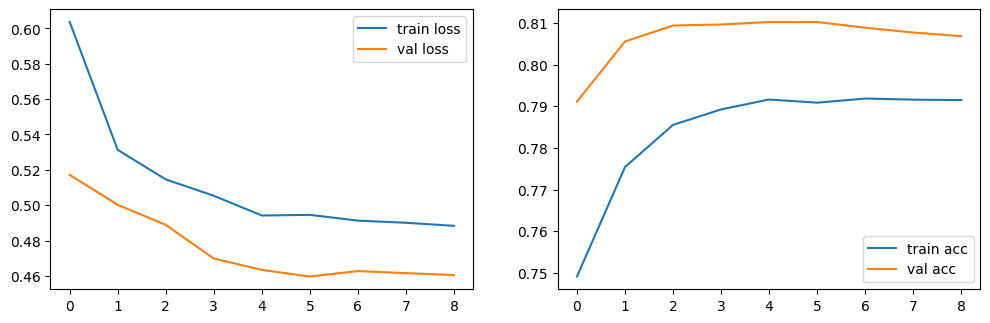

              precision    recall  f1-score   support

    Negative       0.97      0.15      0.26    255325
    Positive       0.37      0.99      0.54    130550

    accuracy                           0.44    385875
   macro avg       0.67      0.57      0.40    385875
weighted avg       0.77      0.44      0.36    385875



<Figure size 600x500 with 0 Axes>

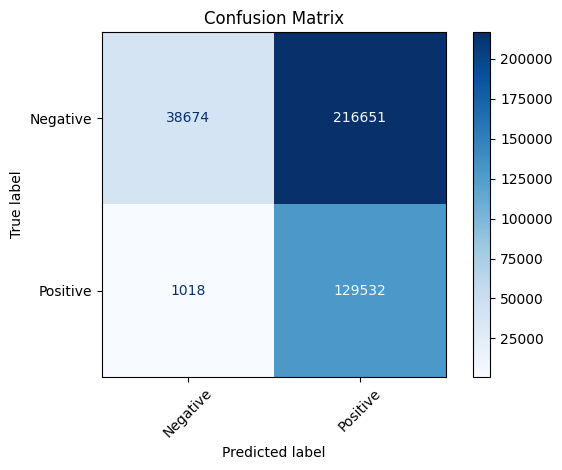


Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      0.15      0.26    255325
    Positive       0.37      0.99      0.54    130550

    accuracy                           0.44    385875
   macro avg       0.67      0.57      0.40    385875
weighted avg       0.77      0.44      0.36    385875



In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation
from sklearn.metrics import classification_report

from utils import (
    plot_training_history,
    plot_confusion_matrix,
    find_optimal_threshold,
    get_extended_report
)

# ─────────────────────────
# Training history
# ─────────────────────────
plot_training_history(history)

# ─────────────────────────
# Predict probabilities (ONCE)
# ─────────────────────────
y_score = model.predict(x_test, verbose=0).ravel()  # sigmoid output
y_true = y_test.flatten()

# ─────────────────────────
# Find optimal threshold
# ─────────────────────────
optimal_threshold = find_optimal_threshold(y_true, y_score)

# ─────────────────────────
# Apply threshold
# ─────────────────────────
y_pred_binary = (y_score > optimal_threshold).astype(int)

# ─────────────────────────
# Optional smoothing
# ─────────────────────────
kernel = 100
y_pred_smoothed = binary_dilation(y_pred_binary, iterations=kernel)

# ─────────────────────────
# Classification report
# ─────────────────────────
print(classification_report(
    y_true,
    y_pred_smoothed,
    target_names=["Negative", "Positive"]
))

# ─────────────────────────
# Confusion matrix
# ─────────────────────────
plot_confusion_matrix(
    y_true,
    y_pred_smoothed,
    ["Negative", "Positive"]
)

# ─────────────────────────
# 🔥 EXTENDED REPORT (HERE)
# ─────────────────────────
get_extended_report(
    y_true=y_true,
    y_pred=y_pred_smoothed,
    y_score=y_score,
    average="macro"
)


In [ ]:

def plot_multiple_examples(X_test, y_test, model, fs, optimal_threshold, 
                          n_examples=10, ylim_factor=1.5):
 
    # Create output folder
    os.makedirs("Model_Predictions", exist_ok=True)

    for idx in range(min(n_examples, len(X_test))):
        # Get data
        audio = X_test[idx].squeeze()
        labels = y_test[idx].squeeze()

        # Raw model output for this example
        preds_raw = model.predict(X_test[idx:idx+1], verbose=0)[0].squeeze()

        # Apply sigmoid to get probabilities
        preds_prob = tf.nn.sigmoid(preds_raw).numpy()
        
        # Apply optimal threshold
        pred_mask = preds_prob > optimal_threshold

        # Create time axis in milliseconds
        time_ms = np.arange(len(audio)) / fs * 1000

        # Create figure
        fig, ax = plt.subplots(figsize=(20, 6))

        # Plot audio waveform
        ax.plot(time_ms, audio, color='black', linewidth=1, label='Audio Signal', zorder=1)

        # Highlight regions where label = 1 (ground truth events - RED)
        for i in range(len(labels)):
            if labels[i] == 1:
                ax.axvspan(time_ms[i], time_ms[i] + (1000/fs), 
                          color=(1.0, 0.0, 0.0, 0.03), zorder=2, edgecolor='none')

        # Highlight regions where predicted mask == True (predicted events - GREEN)
        for i in range(len(pred_mask)):
            if pred_mask[i]:
                ax.axvspan(time_ms[i], time_ms[i] + (1000/fs), 
                          color=(0.0, 1.0, 0.0, 0.03), zorder=3, edgecolor='none')

        # Set y-axis limits with more space (zoomed out)
        y_min, y_max = audio.min(), audio.max()
        y_range = y_max - y_min
        y_center = (y_max + y_min) / 2
        new_range = y_range * ylim_factor
        ax.set_ylim([y_center - new_range/2, y_center + new_range/2])

        # Get updated y-limits
        y_min_plot, y_max_plot = ax.get_ylim()
        y_mid = (y_min_plot + y_max_plot) / 2

        # Grid: major every 1 second (1000 ms)
        x_min, x_max = time_ms[0], time_ms[-1]
        major_start = int(np.ceil(x_min / 1000) * 1000)
        major_ticks = np.arange(major_start, x_max + 1, 1000)
        ax.set_xticks(major_ticks)

        # Grid: minor every 100 ms for better visibility
        minor_start = int(np.ceil(x_min / 100) * 100)
        minor_ticks = np.arange(minor_start, x_max + 1, 100)
        ax.set_xticks(minor_ticks, minor=True)

        ax.grid(which='major', color='black', linestyle='-', linewidth=1, alpha=0.7)
        ax.grid(which='minor', color='grey', linestyle='-', linewidth=0.6, alpha=0.5)

        # Add time labels for minor ticks
        for x_pos in minor_ticks:
            if x_min < x_pos <= x_max:
                ax.text(x_pos, y_mid, f'{int(x_pos)}', rotation=90, 
                       verticalalignment='center', horizontalalignment='right', 
                       fontsize=7, color='grey', alpha=0.7)


        plt.tight_layout()

        # Save figure
        save_path = os.path.join("Model_Predictions", f"example_{idx+1}.png")
        plt.savefig(save_path, dpi=300)
        plt.close(fig)
        print(f"Saved: {save_path}")

# Plot predictions with optimal threshold
plot_multiple_examples(x_test, y_test, model, fs, 0.6, 
                       n_examples=10, ylim_factor=1.5)


/tmp/ipykernel_198211/898062613.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(time_ms[i], time_ms[i] + (1000/fs),
/tmp/ipykernel_198211/898062613.py:39: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(time_ms[i], time_ms[i] + (1000/fs),


Saved: Model_Predictions/example_1.png
Saved: Model_Predictions/example_2.png
Saved: Model_Predictions/example_3.png
Saved: Model_Predictions/example_4.png
Saved: Model_Predictions/example_5.png
Saved: Model_Predictions/example_6.png
Saved: Model_Predictions/example_7.png
Saved: Model_Predictions/example_8.png
Saved: Model_Predictions/example_9.png
Saved: Model_Predictions/example_10.png


## Problem Formulation

In this thesis, the task of spontaneous-activity detection is formulated as a **sequence-to-sequence binary labeling problem**. The input EMG signal is represented as a time-ordered sequence of real-valued measurements:

$$
x = \{x_t\}_{t \in \mathbb{N}}, \quad x_t \in \mathbb{R}
$$

Each time frame in the signal corresponds to either  
- **clean muscle activity**, or  
- **spontaneous activity (SA)**.

The ground-truth annotation is therefore a binary sequence:

$$
y = \{y_t\}_{t \in \mathbb{N}}, \quad y_t \in \{0,1\}
$$

with

$$
y_t =
\begin{cases}
1, & \text{if frame } t \text{ contains spontaneous activity}, \\
0, & \text{otherwise}.
\end{cases}
$$

The goal is to learn a parametric model

$$
f_\theta : \mathbb{R}^N \rightarrow \{0,1\}^N
$$

that maps an EMG signal of length \(N\) to a predicted binary sequence:

$$
\hat{y} = f_\theta(x) = \{\hat{y}_t\}_{t \in \mathbb{N}}
$$

Training consists of minimizing a loss function \(L(y, \hat{y})\) that measures the difference between predictions and ground truth:

$$
\theta^{*} = \arg\min_{\theta} \, L(y, \hat{y})
$$

Because spontaneous-activity events are rare compared to clean frames, the dataset is highly imbalanced. To address this, the model is trained using **focal loss**, which increases the relative weight of the positive class (\(y_t = 1\)) and encourages the model to focus on correctly detecting spontaneous activity.


In [ ]:
#N erwähnen: window grösse
# Teta auch erwähnen: Model Parameter also Gewichte
# stern: ideale Gewichte

# In der Zukunft auch für RF und CNN 